# 06 — Demo: Klasifikacija i objašnjenje predikcije

Ovaj notebook demonstrira finalni (fine-tuned VGG-16) model na jednoj slici, učitavanje, predikcija, i objašnjenje odluke pomoću Grad-CAM tehnike. Prvo poredimo sva tri istrenirana pristupa (baseline, transfer learning, fine-tuning) da pokažemo napredak kroz projekat, pa demonstriramo najbolji model uživo.

## 1. Poređenje modela

Pre nego što demonstriramo finalni model uživo, poredimo sva tri istrenirana pristupa (baseline, transfer learning, fine-tuning) da pokažemo napredak kroz projekat.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# brojke su iz test evaluacija u 02, 03 i 04 notebook-ima - ne računaju se ponovo ovde,
# samo se sabiraju na jedno mesto radi preglednog poređenja
results = pd.DataFrame({
    "Model": ["Baseline (VGG-6)", "Transfer Learning (VGG-16)", "Fine-tuning (VGG-16)"],
    "Accuracy": [0.9030, 0.9810, 0.9900],
    "Precision": [0.8974, 0.9839, 0.9900],
    "Recall": [0.9100, 0.9780, 0.9900],
    "F1-score": [0.9037, 0.9809, 0.9900],
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Baseline (VGG-6),0.903,0.8974,0.910,0.9037
1,Transfer Learning (VGG-16),0.981,0.9839,0.978,0.9809
2,Fine-tuning (VGG-16),0.990,0.9900,0.990,0.9900


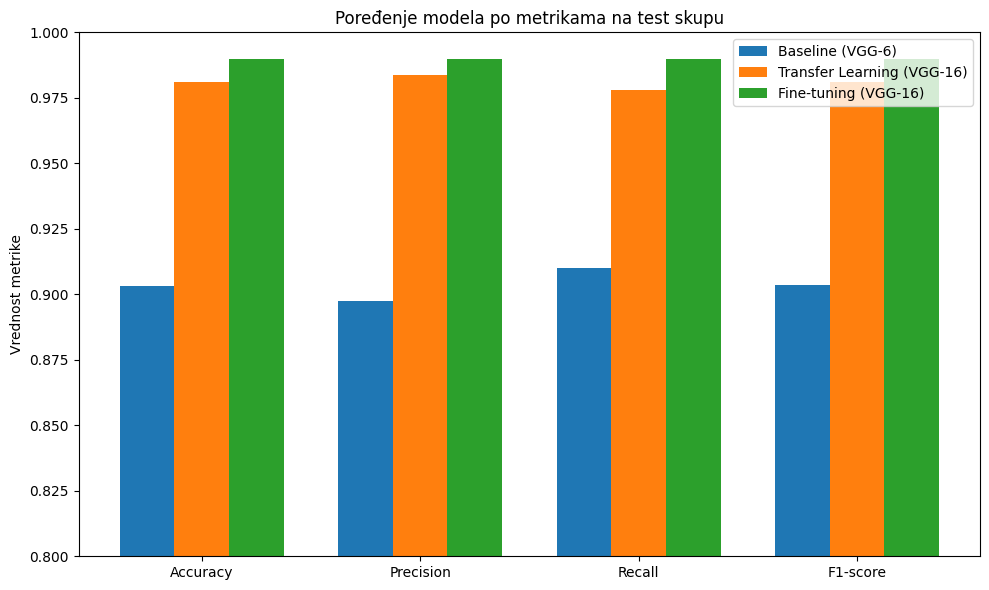

In [ ]:
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

# grupisan bar chart - za svaku metriku tri stubića jedan pored drugog, po jedan za svaki model
for i, row in results.iterrows():
    values = [row[m] for m in metrics]
    ax.bar(x + i * width, values, width, label=row["Model"])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel("Vrednost metrike")
# NAPOMENA: y-osa namerno ne počinje od 0 - sve vrednosti su između 90-99%,
# grafikon od 0 bi sve stubiće prikazao skoro identičnim
ax.set_ylim(0.8, 1.0)
ax.set_title("Poređenje modela po metrikama na test skupu")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Setup i učitavanje modela

Montiramo Drive i proveravamo tačan naziv sačuvanog fine-tuned modela pre učitavanja.


In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

MODEL_DIR = "/content/drive/MyDrive/MU-projekat/models"
print(os.listdir(MODEL_DIR))  # provera tačnog naziva fajla pre učitavanja

Mounted at /content/drive
['vgg16_transfer_learning.keras', 'vgg16_finetuned.keras', 'vgg6_baseline_regularized.keras']


In [ ]:
# učitavamo Mininičin fine-tuned VGG-16 model (najbolji od sva tri) - ne treniramo ništa ponovo
MODEL_PATH = os.path.join(MODEL_DIR, "vgg16_finetuned.keras")
model = tf.keras.models.load_model(MODEL_PATH)
model.summary()

Model: "vgg16_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        257 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 29,268,293 (111.65 MB)

 Trainable params: 7,211,009 (27.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,422,020 (55.02 MB)

## 3. Funkcije za pripremu slike i klasifikaciju


In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input

IMG_SIZE = 224
CLASS_NAMES = ["cat", "dog"]


def load_image_for_display(filepath):
    img = tf.keras.utils.load_img(filepath, target_size=(IMG_SIZE, IMG_SIZE))
    return tf.keras.utils.img_to_array(img) / 255.0  # za prikaz na ekranu


def load_image_for_model(filepath):
    # VAŽNO: model (03/04 notebook) je definisan tako da preprocess_input poziva
    # UNUTAR svog Keras grafa (vidi se u summary() kao get_item/stack/add slojevi
    # pre vgg16 bloka), pa mu prosleđujemo sirove piksele, BEZ /255 i BEZ ručnog
    # preprocess_input - inače bi se priprema primenila dvaput i pokvarila ulaz.
    img = tf.keras.utils.load_img(filepath, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    return np.expand_dims(img_array, axis=0)


def classify_image(filepath):
    model_input = load_image_for_model(filepath)
    probability = model.predict(model_input, verbose=0)[0][0]
    predicted_class = CLASS_NAMES[int(probability >= 0.5)]
    confidence = probability if probability >= 0.5 else 1 - probability
    return predicted_class, confidence, probability

## 4. Izbor slike i test klasifikacije


Odabrana slika za demo: dog.10851.jpg (prava labela: dog )


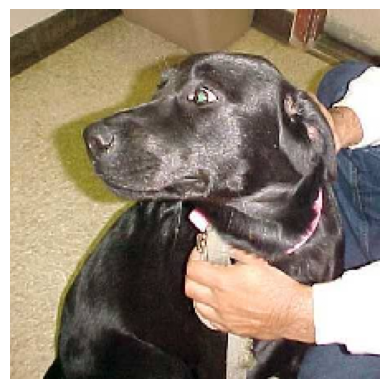

In [ ]:
split_df = pd.read_csv("/content/drive/MyDrive/MU-projekat/data/split.csv")
DATASET_DIR = "/content/drive/MyDrive/MU-projekat/data/dogs-vs-cats/train/train"

test_df = split_df[split_df["split"] == "test"]
# random_state=42 bira UVEK istu sliku - reproducibilno, isti rezultat pri svakom pokretanju
demo_row = test_df.sample(n=1, random_state=42).iloc[0]
demo_filepath = os.path.join(DATASET_DIR, demo_row["filename"])

print("Odabrana slika za demo:", demo_row["filename"], "(prava labela:", demo_row["label"], ")")

display_img = load_image_for_display(demo_filepath)
plt.imshow(display_img)
plt.axis("off")
plt.show()

In [ ]:
# brza provera da priprema/model rade ispravno pre nego što Mina nastavi svoj deo
# (prikaz predikcije, verovatnoća i Grad-CAM)
predicted_class, confidence, raw_probability = classify_image(demo_filepath)

print(f"Prava labela:  {demo_row['label']}")
print(f"Predikcija:    {predicted_class}")
print(f"Pouzdanost:    {confidence * 100:.2f}%")

Prava labela:  dog
Predikcija:    dog
Pouzdanost:    100.00%
